<a href="https://colab.research.google.com/github/JaymeManhica/AndroidFlutter/blob/master/Crescimento%20femenino%20%20e%20masculino%20em%20mo%C3%A7ambique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Comparação de crescimento femenino e masculino e previsao de até 2040

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

Agora vamos importar o dataset

In [2]:
df = pd.read_excel('dataset_mozambique.xlsx')

agora vamos verificaar quais dados ele tem

In [3]:
df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Mozambique,MOZ,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mozambique,MOZ,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,...,55.000000,NaN,51.000000,291.000000,939.000000,877.000000,378.000000,176.000000,NaN,NaN
2,Mozambique,MOZ,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,...,33.990147,33.990147,32.524273,30.917875,30.917875,31.400967,32.367149,31.862745,NaN,NaN
3,Mozambique,MOZ,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,59.995378,68.068593,61.279308,64.569856,79.493618,75.768038,78.188057,76.914524,NaN,NaN
4,Mozambique,MOZ,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,10.710184,7.329978,5.570592,5.172455,4.747434,5.165170,1.911585,1.674934,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1504,Mozambique,MOZ,Land area (sq. km),AG.LND.TOTL.K2,NaN,786380.000000,786380.000000,786380.0000,786380.000000,786380.000000,...,786380.000000,786380.000000,786380.000000,786380.000000,786380.000000,786380.000000,786380.000000,NaN,NaN,NaN
1505,Mozambique,MOZ,Forest area (sq. km),AG.LND.FRST.K2,NaN,NaN,NaN,NaN,NaN,NaN,...,376282.900000,374066.000000,372241.680000,369661.100000,367437.600000,364976.047000,362673.196000,NaN,NaN,NaN
1506,Mozambique,MOZ,Rural land area where elevation is below 5 met...,AG.LND.EL5M.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1507,Mozambique,MOZ,Arable land (% of land area),AG.LND.ARBL.ZS,NaN,3.107912,3.115542,3.1219,3.128259,3.140975,...,7.184822,7.184822,7.184822,7.184822,7.184822,7.184822,7.184822,NaN,NaN,NaN


Este é um dataset disponibilizado pelo banco mundial, que contem varios dados relacionados com o pais mocambicano, como taxa de natalidade, indice de hiv, etc

vamos selecionar as variaeis que queremos estudar e prever

In [4]:
df_population = df[df["Indicator Name"].isin(["Population, female", "Population, male"])]

#método isin() para filtrar mais de um valor na mesma coluna:

Selecionamos duas variaveis, populacao masculina e femenina para estudarmos e fazermos previsao e abaixo mostra-se os dados

In [5]:
df_population

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
30,Mozambique,MOZ,"Population, female",SP.POP.TOTL.FE.IN,3441284.0,3500404.0,3563117.0,3629088.0,3697986.0,3770661.0,...,14144776.0,14562669.0,14992896.0,15432082.0,15887255.0,16353471.0,16832437.0,17327861.0,NaN,NaN
527,Mozambique,MOZ,"Population, male",SP.POP.TOTL.MA.IN,3272411.0,3334532.0,3406247.0,3480740.0,3557075.0,3635760.0,...,13192329.0,13603724.0,14025748.0,14452298.0,14896433.0,15354329.0,15823809.0,16307299.0,NaN,NaN


In [6]:
df_pivot = df_population.set_index("Indicator Name").loc[:, "1960":"2023"]
df_pivot

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Indicator Name,,,,,,,,,,,,,,,,,,,,,
"Population, female",3441284.0,3500404.0,3563117.0,3629088.0,3697986.0,3770661.0,3846295.0,3924734.0,4006663.0,4091885.0,...,13359832.0,13744964.0,14144776.0,14562669.0,14992896.0,15432082.0,15887255.0,16353471.0,16832437.0,17327861.0
"Population, male",3272411.0,3334532.0,3406247.0,3480740.0,3557075.0,3635760.0,3716695.0,3799816.0,3885950.0,3975066.0,...,12428643.0,12802608.0,13192329.0,13603724.0,14025748.0,14452298.0,14896433.0,15354329.0,15823809.0,16307299.0


Vamos estruturar o dataset para analise temporal

In [7]:
df_transposed = df_pivot.T
df_transposed.index = df_transposed.index.astype(int)
df_transposed.head()

Indicator Name,"Population, female","Population, male"
1960,3441284.0,3272411.0
1961,3500404.0,3334532.0
1962,3563117.0,3406247.0
1963,3629088.0,3480740.0
1964,3697986.0,3557075.0


Acima vimos que existe uma diferença entre numero de mulheres e de homens, mas olhando de longe é dificil ver qual é sexo cooom a maioria, por isso vamos montar um grafico

em forma de grafico, vamos ver a projecao temporal

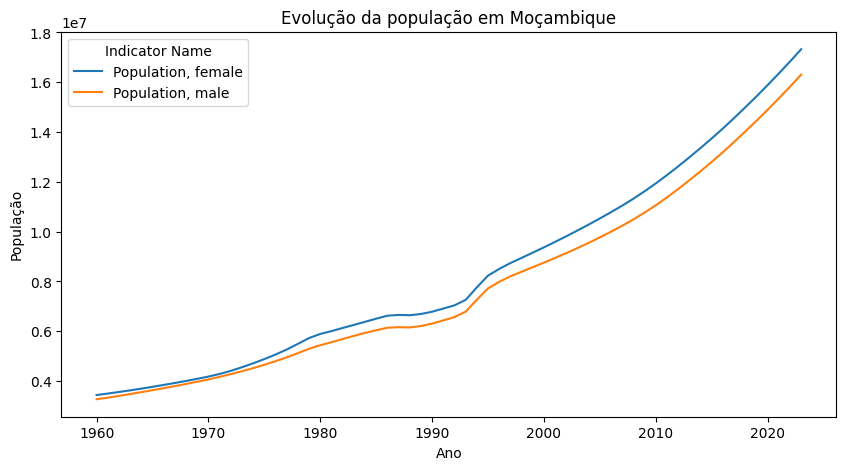

In [8]:
import matplotlib.pyplot as plt

df_transposed.plot(figsize=(10,5))
plt.title("Evolução da população em Moçambique")
plt.xlabel("Ano")
plt.ylabel("População")
plt.show()

claramente vimos quem em moçambique desde 1960 até 2024 o numero de mulheres sempre esteve acima, isto é, em moçambique há mais mulheres que homens. e tambem
Entre 1960–1980 → crescimento mais lento

Depois de 1995 → crescimento claramente mais rápido

**Isto indica mudança estrutural:**
melhorias na saúde

redução da mortalidade

possível aumento da taxa de natalidade

In [10]:
df_transposed["Diferença"] = df_transposed["Population, female"] - df_transposed["Population, male"]
df_transposed

Indicator Name,"Population, female","Population, male",Diferença
1960,3441284.0,3272411.0,168873.0
1961,3500404.0,3334532.0,165872.0
1962,3563117.0,3406247.0,156870.0
1963,3629088.0,3480740.0,148348.0
1964,3697986.0,3557075.0,140911.0
...,...,...,...
2019,15432082.0,14452298.0,979784.0
2020,15887255.0,14896433.0,990822.0
2021,16353471.0,15354329.0,999142.0
2022,16832437.0,15823809.0,1008628.0


A análise da evolução populacional em Moçambique revela um crescimento contínuo e progressivamente acelerado ao longo das últimas décadas, com maior intensidade a partir da década de 1990. Este comportamento sugere melhorias nas condições de vida, nomeadamente no acesso à saúde e redução da mortalidade.

Observa-se que a população feminina é consistentemente superior à masculina em todo o período analisado, o que pode estar associado a uma maior esperança de vida das mulheres ou a fatores socioeconómicos que afetam a população masculina de forma diferenciada.

Adicionalmente, a diferença absoluta entre os dois grupos tem aumentado significativamente ao longo do tempo, passando de cerca de 168 mil em 1960 para mais de 1 milhão em 2023, indicando um crescimento mais acentuado da população feminina.

No geral, os dados evidenciam uma tendência demográfica estável, sem flutuações abruptas, o que reforça a consistência do crescimento populacional no país.

In [11]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_transposed.index.values.reshape(-1,1)
y = df_transposed["Population, female"].values

model = LinearRegression()
model.fit(X, y)

future_years = np.array([2025, 2030, 2040]).reshape(-1,1)
predictions = model.predict(future_years)

predictions

array([15339882.65888274, 16379135.54407048, 18457641.31444597])

Com base no modelo de regressão linear aplicado, observa-se uma tendência de crescimento contínuo da população feminina, com projeções que indicam cerca de 18,4 milhões até 2040. No entanto, o modelo utilizado apresenta limitações, uma vez que assume uma relação linear entre o tempo e a população, enquanto os dados históricos evidenciam um crescimento acelerado. Assim, é provável que as previsões obtidas estejam subestimadas, especialmente em horizontes temporais mais longos.

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly.fit(X, y)

pred_poly = model_poly.predict(future_years)
pred_poly

array([17566019.46941185, 19631404.55913734, 24189729.82379723])

A aplicação de um modelo de regressão polinomial permitiu captar melhor a tendência de crescimento acelerado observada nos dados históricos, resultando em previsões significativamente superiores às obtidas com regressão linear. Enquanto o modelo linear assume um crescimento constante, o modelo polinomial ajusta-se à curvatura dos dados, refletindo uma dinâmica demográfica mais realista.

No entanto, este modelo pode introduzir alguma sobrestimação em previsões de longo prazo, devido à sua sensibilidade a variações nos dados históricos. Assim, embora o modelo polinomial apresente melhor ajuste aos dados observados, os seus resultados devem ser interpretados com cautela.

In [13]:
y_male = df_transposed["Population, male"].values

model_poly_male = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly_male.fit(X, y_male)

pred_male = model_poly_male.predict(future_years)
pred_male

array([16453713.38994598, 18417360.8354187 , 22762626.09873009])

As projeções obtidas através do modelo polinomial indicam que tanto a população masculina como feminina continuarão a crescer de forma significativa nas próximas décadas. No entanto, observa-se que a população feminina mantém uma vantagem consistente sobre a masculina, com uma diferença que tende a aumentar ao longo do tempo.

Em particular, a diferença projetada cresce de aproximadamente 1,1 milhão em 2025 para cerca de 1,4 milhão em 2040, reforçando a tendência já observada nos dados históricos. Este comportamento sugere que o crescimento da população feminina ocorre a um ritmo ligeiramente superior, possivelmente associado a fatores como maior esperança de vida ou diferenças nas taxas de mortalidade entre os géneros.

Contudo, importa salientar que estas previsões baseiam-se na continuidade das tendências passadas e na utilização de um modelo polinomial, o qual pode amplificar o crescimento em horizontes temporais mais longos, devendo os resultados ser interpretados com cautela.

In [14]:
diff_future = pred_poly - pred_male
diff_future

array([1112306.07946587, 1214043.72371864, 1427103.72506714])

A análise do rácio entre a população feminina e masculina indica um aumento progressivo ao longo do tempo, sugerindo um crescimento relativamente mais acelerado da população feminina. No entanto, os valores projetados pelo modelo polinomial revelam um aumento acentuado deste rácio, atingindo níveis que podem não ser demograficamente realistas.

Este comportamento evidencia uma limitação do modelo utilizado, que tende a amplificar tendências existentes nos dados históricos, resultando em possíveis sobrestimações. Assim, embora o modelo capte a direção da tendência, os valores absolutos devem ser interpretados com cautela.

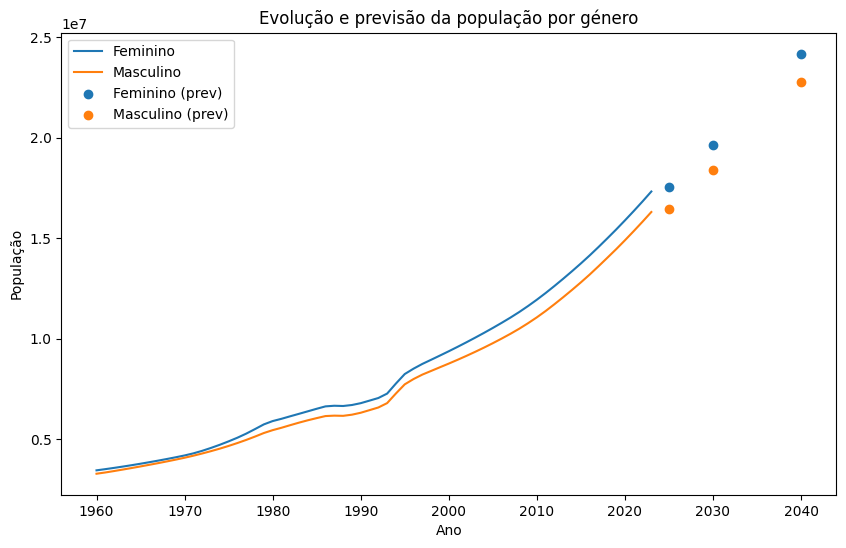

In [17]:
plt.figure(figsize=(10,6))

# histórico
plt.plot(df_transposed.index, df_transposed["Population, female"], label="Feminino")
plt.plot(df_transposed.index, df_transposed["Population, male"], label="Masculino")

# previsões
plt.scatter(anos_futuros, pred_poly, label="Feminino (prev)", marker='o')
plt.scatter(anos_futuros, pred_male, label="Masculino (prev)", marker='o')

plt.title("Evolução e previsão da população por género")
plt.xlabel("Ano")
plt.ylabel("População")
plt.legend()

plt.show()

O gráfico da diferença populacional evidencia um crescimento contínuo ao longo do tempo, confirmando a tendência observada nos dados históricos. As previsões indicam que esta diferença continuará a aumentar, embora de forma mais acentuada nos modelos polinomiais. No entanto, essa aceleração pode estar sobrestimada, sugerindo a necessidade de cautela na interpretação dos resultados.

A comparação entre modelos evidencia a importância da escolha adequada da técnica de previsão, uma vez que diferentes abordagens podem conduzir a interpretações distintas sobre a evolução futura da população.